# STAT 531 Homework 5

#### Student Name: Amelia Nguyen
#### Date: March 31, 2026

## Question 1: Multiple Choice

Completed

## Question 2: Classification approach
Suppose we produce ten bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to each bootstrapped sample and, for a specific value of X, produce 10 estimates of P(Class is Red|X):

0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, and 0.75.

There are two common ways to combine these results together into a single class prediction. One is the majority vote approach discussed in this chapter. The second approach is to classify based on the average probability. In this example, what is the final classification under each of these two approaches

**Answer**:

Approach 1: 
* Using majority vote.
* Suppose the threshold is 0.5, the result will be: Green, Green, Green, Green, Red, Red, Red, Red, and Red
    * Green: 4
    * Red: 5
* Classification result: Red

Approach 2: 
* Using average probability
* Avg probability = (0.1 + 0.15 + 0.2 + 0.2 + 0.55 + 0.6 + 0.6 + 0.65 + 0.7 + 0.75) / 10 = 0.45 < 0.5 (Suppose the threshold is 0.5)
* Classification result: Green



## Question 3: OJ dataset

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from ISLP import *
from ISLP.models import ModelSpec as MS
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import *

### (a)
Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.

In [123]:
data = load_data("OJ")

In [125]:
data.head(3)

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.50,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.60,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.68,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1


In [126]:
data['Purchase'] = (data['Purchase'] == 'CH').astype(int)

In [127]:
X = data.drop(columns={'Purchase'})
y = data['Purchase']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 800, random_state = 16)

In [128]:
X_train.shape

(800, 17)

In [129]:
X_test.shape

(270, 17)

### (b)
Fit a tree to the training data, with Purchase as the response and the other variables as predictors. Use the summary() function to produce summary statistics about the tree, and describe the results obtained. How many terminal nodes does the tree have?


In [130]:
data.Purchase.unique()

array([1, 0])

In [131]:
X_train = pd.get_dummies(X_train, drop_first=True)

In [132]:
X_test = pd.get_dummies(X_test, drop_first=True)

In [138]:
clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


As Python cannot call summary() function for the summary statistics about the tree. I'm using other functions to produce information to achieve the closest information to R .summary() on a rpart or tree.

In [145]:
print("Tree Information:")
print("Number of terminal nodes:", clf.get_n_leaves())
print("Tree depth:", clf.get_depth())

Tree Information:
Number of terminal nodes: 165
Tree depth: 15


In [172]:
# Export textual representation
print(export_text(clf,
                  feature_names= list(X_train.columns),
                  show_weights=True))


|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.14
|   |   |   |--- PriceDiff <= -0.29
|   |   |   |   |--- WeekofPurchase <= 273.50
|   |   |   |   |   |--- LoyalCH <= 0.03
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- LoyalCH >  0.03
|   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- WeekofPurchase >  273.50
|   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |--- PriceDiff >  -0.29
|   |   |   |   |--- PctDiscMM <= 0.20
|   |   |   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |   |   |--- WeekofPurchase <= 237.50
|   |   |   |   |   |   |   |--- WeekofPurchase <= 236.50
|   |   |   |   |   |   |   |   |--- weights: [18.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- WeekofPurchase >  236.50
|   |   |   |   |   |   |   |   |--- SalePriceMM <= 2.04
|   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- SalePrice

In [146]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_}).sort_values(by="importance", ascending=False)
print("Feature Importance:")
feature_importance

Feature Importance:


,feature,importance
8,LoyalCH,0.614401
0,WeekofPurchase,0.102579
11,PriceDiff,0.085548
14,ListPriceDiff,0.051883
1,StoreID,0.031623
15,STORE,0.022855
9,SalePriceMM,0.018287
13,PctDiscCH,0.013635
2,PriceCH,0.012107
6,SpecialCH,0.009940


In [149]:
# Class distribution at each terminal node
leaf_ids = clf.apply(X_train)
df = pd.DataFrame({'leaf_id': leaf_ids, 'class': y_train})
summary = df.groupby('leaf_id')['class'].value_counts().unstack(fill_value=0)
summary['total'] = summary.sum(axis=1)
summary.reset_index()
print("Class distribution at each terminal node")
summary

Class distribution at each terminal node


class,0,1,total
leaf_id,,,
6,1,0,1
7,0,2,2
8,4,0,4
13,18,0,18
15,1,0,1
...,...,...,...
322,2,0,2
323,0,1,1
326,0,1,1


### (c)
Predict the response on the test data, and produce a confusion matrix comparing the test labels to the predicted test labels. What is the test error rate?

In [150]:
y_pred = clf.predict(X_test)

In [151]:
confusion = confusion_table(y_test, y_pred)
confusion

Truth,0,1
Predicted,,
0,91,23
1,33,123


In [152]:
print(f"Test error rate = {np.mean(y_pred != y_test)}")

Test error rate = 0.2074074074074074


### (d)
Apply the cv.tree() function to the training set in order to determine the optimal tree size.

**Answer:** Python doesn't have `cv.tree()`, instead, I'll apply the cross validation method to prune the tree as instructed from the book's labs to achieve similar result.

In [153]:
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(10,
                  random_state=1,
                  shuffle=True)
grid = skm.GridSearchCV(clf,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, y_train)
grid.best_score_

np.float64(0.8137500000000001)

In [154]:
best_ = grid.best_estimator_
print("Optimal terminal nodes:", best_.tree_.n_leaves)
print("Optimal tree depth:", best_.get_depth())


Optimal terminal nodes: 23
Optimal tree depth: 7


### (e)
Produce a plot with tree size on the x-axis and cross-validated classification error rate on the y-axis.
Which tree size corresponds to the lowest cross-validated classification error rate?

In [158]:
mean_accuracy = grid.cv_results_['mean_test_score']
cv_error = 1 - mean_accuracy
tree_size = []
for alpha in ccp_path.ccp_alphas:
    clf_temp = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha)
    clf_temp.fit(X_train, y_train)
    tree_size.append(clf_temp.get_n_leaves())

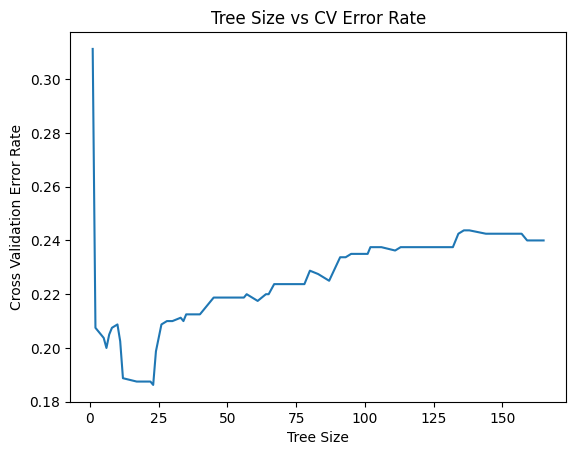

In [174]:
plt.plot(tree_sizes, cv_error)
plt.xlabel("Tree Size")
plt.ylabel("Cross Validation Error Rate")
plt.title("Tree Size vs CV Error Rate")
plt.show()

In [160]:
best_size = np.argmin(cv_error)
print("Best tree size:", tree_size[best_size])
print("Lowest CV error:", cv_error[best_size])

Best tree size: 23
Lowest CV error: 0.18624999999999992


### (f)
Produce a pruned tree corresponding to the optimal tree size obtained using cross-validation. If cross-validation does not lead to selection of a pruned tree, then create a pruned tree with five terminal nodes.


In [161]:
alpha = ccp_path.ccp_alphas[np.where(np.array(tree_size) == tree_size[best_size])[0][0]]
pruned_clf = DecisionTreeClassifier(random_state=1, ccp_alpha = alpha)
pruned_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [162]:
y_pred = pruned_clf.predict(X_test)

In [163]:
np.mean(y_pred != y_test)

np.float64(0.18518518518518517)

### (g) 
Apply boosting (n.tree = 1000, depth=2) and random forests (m=p/3, ntree=50) to the OJ data. Be sure to fit the models on a training set and to evaluate their test error rates.


**Boosting**

In [164]:
boosting = GradientBoostingClassifier(n_estimators=1000,
                   max_depth=2,
                   random_state=1)
boosting.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [165]:
boosting_pred = boosting.predict_proba(X_test)[:, 1]
boosting_pred = (boosting_pred >= 0.5).astype(int)

In [166]:
print(f"Test error rate: {np.mean(boosting_pred != y_test)}")

Test error rate: 0.18518518518518517


**Random Forest**

In [169]:
RF = RandomForestClassifier(max_features=int(X_train.shape[1]/3),
                n_estimators=50,
                random_state=1).fit(X_train, y_train)

In [170]:
RF_pred = RF.predict_proba(X_test)[:, 1]
RF_pred = (RF_pred >= 0.5).astype(int)

In [171]:
print(f"Test error rate: {np.mean(RF_pred != y_test)}")

Test error rate: 0.1962962962962963


Boosting has a lower test error rate compared to Random Forest